In [30]:
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import subprocess
import numpy as np
import scipy.stats as stats
from itertools import combinations
from scipy.spatial.distance import cosine

In [3]:
new_dir = "/home/jingqi/RNALocateV3.0/Data"
os.chdir(new_dir)
os.getcwd()

'/home/jingqi/RNALocateV3.0/Data'

In [23]:
fasta_file = "Raw/FASTA_full.txt"
prob_file = "Main/Probabilities.csv"
output_file = "Gene_Filtered_bi.csv"
output_file_cos = "Gene_Filtered_cos.csv" 

threshold = 0.75
SIMILARITY_THRESHOLD = 0.5

## Binary

In [14]:

transcript_to_gene = {}
with open(fasta_file, 'r') as f:
    for line in f:
        if line.startswith('>'):
            clean_line = line.strip()[1:]
            parts = clean_line.split('|')
            if len(parts) >= 2:
                transcript_id = parts[0]
                gene_symbol = parts[1]
                transcript_to_gene[transcript_id] = gene_symbol

# Load Predictions and Map Genes
df = pd.read_csv(prob_file)
df['Gene'] = df['sequence_id'].map(transcript_to_gene)
df = df.dropna(subset=['Gene'])

# Binarize the probability columns at the 0.75 threshold
prob_cols = [col for col in df.columns if col.endswith('_prob')]
for col in prob_cols:
    df[col] = (df[col] > 0.75).astype(int)

# 4. Merge compartmental granularities (Logical OR gate)
cyto_cols = [c for c in df.columns if c.lower() in ['cytoplasm_prob', 'cytosol_prob']]
nuc_cols = [c for c in df.columns if c.lower() in ['chromatin_prob', 'nucleolus_prob', 'nucleus_prob', 'nucleoplasm_prob']]

if cyto_cols:
    df['Cytoplasm'] = df[cyto_cols].max(axis=1)
if nuc_cols:
    df['Nucleus'] = df[nuc_cols].max(axis=1)

# Drop the granular columns to prevent downstream multicollinearity
df.drop(columns=cyto_cols + nuc_cols, inplace=True, errors='ignore')

# Clean up remaining location column names and build the SCL Profile
loc_cols = [c for c in df.columns if c not in ['sequence_id', 'Gene']]

# Strip '_prob' suffix from any remaining unmerged columns (e.g., exosome_prob -> Exosome)
rename_dict = {c: c.replace('_prob', '').capitalize() for c in loc_cols if c.endswith('_prob')}
df.rename(columns=rename_dict, inplace=True)
loc_cols = [rename_dict.get(c, c) for c in loc_cols]

def get_binary_profile(row):
    locations = [col for col in loc_cols if row[col] == 1]
    return ",".join(sorted(locations)) if locations else "None"

df['SCL_Profile'] = df.apply(get_binary_profile, axis=1)

# Filter for variance at the Gene level based on the newly merged profiles
def has_scl_variance(group):
    if len(group) == 1:
        return False
    unique_profiles = group['SCL_Profile'].drop_duplicates()
    return len(unique_profiles) > 1

dynamic_genes = df.groupby('Gene').filter(has_scl_variance)

# Format and Export
final_output = dynamic_genes[['Gene', 'sequence_id', 'SCL_Profile'] + loc_cols].copy()
final_output.sort_values(by=['Gene', 'sequence_id'], inplace=True)
final_output.to_csv(output_file, index=False)

print(f"Total raw transcripts mapped: {len(df)}")
print(f"Total unique genes analyzed: {df['Gene'].nunique()}")
print(f"Genes retained demonstrating merged SCL variance: {final_output['Gene'].nunique()}")
print(f"Transcripts exported: {len(final_output)}")

Total raw transcripts mapped: 5783
Total unique genes analyzed: 728
Genes retained demonstrating merged SCL variance: 709
Transcripts exported: 5729


## Cosine

In [26]:
# 1. Parse FASTA mapping
transcript_to_gene = {}
with open(fasta_file, 'r') as f:
    for line in f:
        if line.startswith('>'):
            clean_line = line.strip()[1:]
            parts = clean_line.split('|')
            if len(parts) >= 2:
                transcript_id = parts[0]
                gene_symbol = parts[1]
                transcript_to_gene[transcript_id] = gene_symbol

# 2. Load Predictions and Map Genes
df = pd.read_csv(prob_file)
df['Gene'] = df['sequence_id'].map(transcript_to_gene)
df = df.dropna(subset=['Gene'])

# 3. Merge nested compartments via continuous max pooling
cyto_cols = [c for c in df.columns if c.lower() in ['cytoplasm_prob', 'cytosol_prob']]
nuc_cols = [c for c in df.columns if c.lower() in ['chromatin_prob', 'nucleolus_prob', 'nucleus_prob', 'nucleoplasm_prob']]

if cyto_cols:
    df['Cytoplasm_prob'] = df[cyto_cols].max(axis=1)
if nuc_cols:
    df['Nucleus_prob'] = df[nuc_cols].max(axis=1)

df.drop(columns=cyto_cols + nuc_cols, inplace=True, errors='ignore')
prob_cols = [col for col in df.columns if col.endswith('_prob')]

# 4. Calculate the absolute minimum pairwise similarity for each gene
gene_records = []

for gene, group in df.groupby('Gene'):
    # Discard genes with only one transcript; they possess zero comparative variance
    if len(group) < 2:
        continue
        
    vectors = group[prob_cols].values
    min_sim = 1.0 # Initialize at perfect similarity
    
    # Evaluate every unique transcript pair
    for i, j in combinations(range(len(vectors)), 2):
        if np.all(vectors[i] == 0) or np.all(vectors[j] == 0):
            sim = 0.0
        else:
            sim = 1 - cosine(vectors[i], vectors[j])
            
        if sim < min_sim:
            min_sim = sim
            
    gene_records.append({
        'Gene': gene, 
        'Min_Transcript_Similarity': min_sim,
        'Transcript_Count': len(group)
    })

# 5. Build and sort the ranking matrix
ranking_df = pd.DataFrame(gene_records)

# Sorting SMALLEST to BIGGEST so the most severe spatial translocations are at the top
ranking_df.sort_values(by='Min_Transcript_Similarity', ascending=True, inplace=True)

ranking_df.to_csv(output_file_cos, index=False)

print(f"Total multi-transcript genes analyzed: {len(ranking_df)}")
print(f"Top 5 most divergent genes (Smallest Similarity):\n{ranking_df.head()}")
print(f"\nRanking saved to: {output_file_cos}")

Total multi-transcript genes analyzed: 728
Top 5 most divergent genes (Smallest Similarity):
            Gene  Min_Transcript_Similarity  Transcript_Count
319       Lhfpl2               2.463585e-12                 9
373        Mtif2               7.169226e-10                 8
649        Tfdp2               8.240236e-10                16
362  Mir181a-1hg               2.333515e-08                41
253      Herpud1               1.105033e-07                 6

Ranking saved to: Gene_Filtered_bi.csv


In [35]:
TARGET_GENE = "Plk2"
fasta_file = "Raw/FASTA_full.txt"
prob_file = "Main/Probabilities.csv" 

transcript_to_gene = {}
with open(fasta_file, 'r') as f:
    for line in f:
        if line.startswith('>'):
            clean_line = line.strip()[1:]
            parts = clean_line.split('|')
            if len(parts) >= 2:
                transcript_id = parts[0]
                gene_symbol = parts[1]
                transcript_to_gene[transcript_id] = gene_symbol

df = pd.read_csv(prob_file)
df['Gene'] = df['sequence_id'].map(transcript_to_gene)

gcnt2_df = df[df['Gene'] == TARGET_GENE].copy()

cyto_cols = [c for c in gcnt2_df.columns if c.lower() in ['cytoplasm_prob', 'cytosol_prob']]
nuc_cols = [c for c in gcnt2_df.columns if c.lower() in ['chromatin_prob', 'nucleolus_prob', 'nucleus_prob', 'nucleoplasm_prob']]

if cyto_cols:
    gcnt2_df['Cytoplasm_prob'] = gcnt2_df[cyto_cols].max(axis=1)
if nuc_cols:
    gcnt2_df['Nucleus_prob'] = gcnt2_df[nuc_cols].max(axis=1)

gcnt2_df.drop(columns=cyto_cols + nuc_cols, inplace=True, errors='ignore')

prob_cols = [col for col in gcnt2_df.columns if col.endswith('_prob')]

print(f"Analyzing {len(gcnt2_df)} transcripts for {TARGET_GENE}")
print(f"Dimensionality: {len(prob_cols)} compartments\n")

vectors = gcnt2_df[prob_cols].values
transcript_ids = gcnt2_df['sequence_id'].values

for i, j in combinations(range(len(vectors)), 2):
    if np.all(vectors[i] == 0) or np.all(vectors[j] == 0):
        sim = 0.0
    else:
        sim = 1 - cosine(vectors[i], vectors[j])
        
    if abs(sim - 0.408248) < 0.01:
        print(f"Match Found: Similarity = {sim:.6f}")
        print(f"Transcript 1 ({transcript_ids[i]}):")
        for col, val in zip(prob_cols, vectors[i]):
            print(f"  {col}: {val:.4f}")
            
        print(f"Transcript 2 ({transcript_ids[j]}):")
        for col, val in zip(prob_cols, vectors[j]):
            print(f"  {col}: {val:.4f}")
        print("-" * 40)

Analyzing 5 transcripts for Plk2
Dimensionality: 7 compartments

Match Found: Similarity = 0.408248
Transcript 1 (ENSMUST00000022212.9):
  endoplasmic reticulum_prob: 0.0000
  extracellular region_prob: 1.0000
  membrane_prob: 1.0000
  mitochondrion_prob: 1.0000
  ribosome_prob: 1.0000
  Cytoplasm_prob: 1.0000
  Nucleus_prob: 1.0000
Transcript 2 (ENSMUST00000225156.2):
  endoplasmic reticulum_prob: 0.0000
  extracellular region_prob: 1.0000
  membrane_prob: 0.0000
  mitochondrion_prob: 0.0000
  ribosome_prob: 0.0000
  Cytoplasm_prob: 0.0000
  Nucleus_prob: 0.0000
----------------------------------------
Match Found: Similarity = 0.408248
Transcript 1 (ENSMUST00000022212.9):
  endoplasmic reticulum_prob: 0.0000
  extracellular region_prob: 1.0000
  membrane_prob: 1.0000
  mitochondrion_prob: 1.0000
  ribosome_prob: 1.0000
  Cytoplasm_prob: 1.0000
  Nucleus_prob: 1.0000
Transcript 2 (ENSMUST00000225340.2):
  endoplasmic reticulum_prob: 0.0000
  extracellular region_prob: 1.0000
  membran

Statistical Summary of Minimum Cosine Similarities:
count    7.280000e+02
mean     4.534771e-01
std      2.140424e-01
min      2.463585e-12
1%       1.045777e-06
5%       2.454084e-03
10%      1.965627e-01
25%      4.082483e-01
50%      4.082484e-01
75%      5.006369e-01
90%      7.577436e-01
95%      9.091421e-01
max      1.000000e+00
Name: Min_Transcript_Similarity, dtype: float64

Distribution histogram saved to: Similarity_Distribution_Plot.png


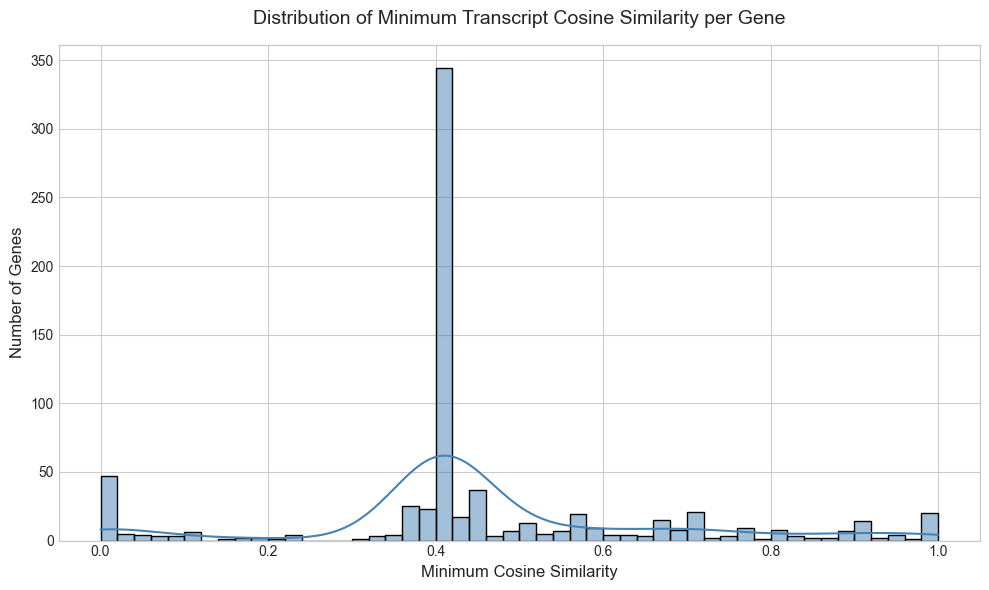

In [31]:
input_file = output_file_cos

# Load the ranked similarity data
df = pd.read_csv(input_file)

# Print the hard numerical boundaries
print("Statistical Summary of Minimum Cosine Similarities:")
print(df['Min_Transcript_Similarity'].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]))

# Generate the distribution plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    df['Min_Transcript_Similarity'], 
    bins=50, 
    kde=True, 
    color='steelblue', 
    ax=ax
)

ax.set_title('Distribution of Minimum Transcript Cosine Similarity per Gene', fontsize=14, pad=15)
ax.set_xlabel('Minimum Cosine Similarity', fontsize=12)
ax.set_ylabel('Number of Genes', fontsize=12)

plt.tight_layout()

# Save the plot instead of using .show() to prevent rendering blockages in some environments
output_image = "Similarity_Distribution_Plot.png"
plt.savefig(output_image, dpi=300)
print(f"\nDistribution histogram saved to: {output_image}")

## Export gene list

In [25]:
input_csv = "Gene_Filtered_cos.csv"
output_txt = "Gene_Filtered_cos.txt"

df = pd.read_csv(input_csv)

# Extract unique genes, drop any potential nulls, and sort alphabetically
unique_genes = df['Gene'].dropna().unique()
unique_genes.sort()

# Write to a text file, one gene per line
with open(output_txt, 'w') as f:
    for gene in unique_genes:
        f.write(f"{gene}\n")

print(f"Successfully extracted {len(unique_genes)} unique genes.")
print(f"List saved to: {output_txt}")

Successfully extracted 542 unique genes.
List saved to: Gene_Filtered_cos.txt
